In [10]:
%config InlineBackend.figure_format = 'svg'

In [11]:
import os

# ============================================
# Output Directory Setup
# ============================================

from pathlib import Path

REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(exist_ok=True)

print(f"Reports directory ready at: {os.path.abspath(REPORT_DIR)}")

Reports directory ready at: /workspace/02_SystemArchitecture/BehavioralModels/reports



Scintillator: NaI(Tl)
Light Yield: 38,000 photons/MeV

Crystal: 25.4 mm | SiPM: 3.0x3.0 mm
  Geometric coverage:   1.78%
  Effective coverage:   1.24%
  N_photons:             25156
  N_detected:              109
  sigma (RMS):          9.56%
  FWHM:                22.51%

Crystal: 25.4 mm | SiPM: 6.0x6.0 mm
  Geometric coverage:   7.10%
  Effective coverage:   4.97%
  N_photons:             25156
  N_detected:              438
  sigma (RMS):          4.78%
  FWHM:                11.25%

Crystal: 25.4 mm | SiPM: 12.0x12.0 mm
  Geometric coverage:  28.42%
  Effective coverage:  19.89%
  N_photons:             25156
  N_detected:             1752
  sigma (RMS):          2.39%
  FWHM:                 5.63%

Scintillator: LaBr3(Ce)
Light Yield: 63,000 photons/MeV

Crystal: 25.4 mm | SiPM: 3.0x3.0 mm
  Geometric coverage:   1.78%
  Effective coverage:   1.24%
  N_photons:             41706
  N_detected:              181
  sigma (RMS):          7.42%
  FWHM:                17.48%

Crystal: 

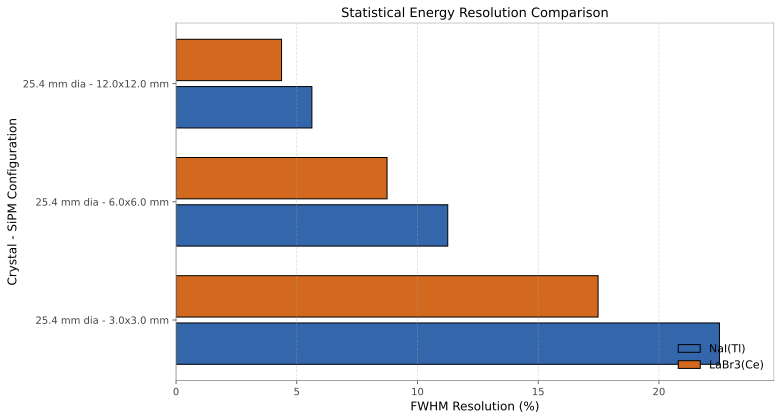

In [18]:
# ============================================
# Horizontal Comparison Plot
# ============================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import yaml
import numpy as np
from pathlib import Path

from models.scintillation_resolution_model import (
    geometric_coverage_fraction,
    apply_optical_efficiency,
    statistical_resolution_percent,
)

# ============================================
# Configuration
# ============================================

CONFIG_PATH = "config.yaml"
STUDY_NAME = "resolution_geometry_study"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

study = cfg[STUDY_NAME]

# Extract study parameters
physics = study["physics"]
geometry = study["geometry"]
scintillators = study["scintillators"]

energy_mev = physics["energy_mev"]
pde = physics["pde"]
optical_eff = physics["optical_efficiency"]

crystal_diameters = geometry["crystal_diameters_mm"]
sipm_sizes = geometry["sipm_sizes_mm"]

# ============================================
# Build Resolution Matrix
# ============================================

resolution_matrix = {}

for scint_name, scint_data in scintillators.items():

    light_yield = scint_data["light_yield_ph_per_mev"]
    
    print(f"\n{'='*60}")
    print(f"Scintillator: {scint_name}")
    print(f"Light Yield: {light_yield:,} photons/MeV")
    print(f"{'='*60}")

    matrix = np.zeros((len(crystal_diameters), len(sipm_sizes)))

    for i, D in enumerate(crystal_diameters):
        for j, s in enumerate(sipm_sizes):

            geo_fraction = geometric_coverage_fraction(D, s)
            coverage = apply_optical_efficiency(geo_fraction, optical_eff)
            
            # Calculate number of detected photons
            n_photons = light_yield * energy_mev
            n_detected = n_photons * coverage * pde

            resolution_percent = statistical_resolution_percent(
                light_yield=light_yield,
                energy_mev=energy_mev,
                coverage=coverage,
                pde=pde,
            )
            
            sigma_rms = resolution_percent / 2.355

            matrix[i, j] = resolution_percent
            
            print(f"\nCrystal: {D} mm | SiPM: {s}x{s} mm")
            print(f"  Geometric coverage: {geo_fraction*100:6.2f}%")
            print(f"  Effective coverage: {coverage*100:6.2f}%")
            print(f"  N_photons:          {n_photons:8.0f}")
            print(f"  N_detected:         {n_detected:8.0f}")
            print(f"  sigma (RMS):        {sigma_rms:6.2f}%")
            print(f"  FWHM:               {resolution_percent:6.2f}%")

    resolution_matrix[scint_name] = matrix

print(f"\n{'='*60}")
print("Resolution matrix built successfully.")
print(f"{'='*60}\n")

# ============================================
# Styling
# ============================================

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ============================================
# Prepare Labels
# ============================================

crystal_labels = [f"{D} mm dia" for D in crystal_diameters]
sipm_labels = [f"{s}x{s} mm" for s in sipm_sizes]

config_labels = []
scint_names = list(resolution_matrix.keys())

if len(scint_names) < 2:
    raise ValueError("Need at least two scintillators for comparison plot.")

vals_1 = []
vals_2 = []

for i, D in enumerate(crystal_diameters):
    for j, s in enumerate(sipm_sizes):

        config_labels.append(f"{crystal_labels[i]} - {sipm_labels[j]}")
        vals_1.append(resolution_matrix[scint_names[0]][i, j])
        vals_2.append(resolution_matrix[scint_names[1]][i, j])

# ============================================
# Plot
# ============================================

fig, ax = plt.subplots(figsize=(11, 6))

y = np.arange(len(config_labels))
offset = 0.2

ax.barh(y - offset, vals_1, height=0.35,
        color="#3366AA", edgecolor="black",
        label=scint_names[0])

ax.barh(y + offset, vals_2, height=0.35,
        color="#D2691E", edgecolor="black",
        label=scint_names[1])

ax.set_xlabel("FWHM Resolution (%)")
ax.set_ylabel("Crystal - SiPM Configuration")
ax.set_title("Statistical Energy Resolution Comparison")

ax.set_yticks(y)
ax.set_yticklabels(config_labels)

ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.spines["right"].set_color("#BBBBBB")
ax.spines["top"].set_color("#BBBBBB")

ax.tick_params(axis='x', colors='#444444')
ax.tick_params(axis='y', colors='#444444')

ax.grid(True, axis="x", linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_xlim(0, max(max(vals_1), max(vals_2)) * 1.1)

ax.legend(frameon=False, loc="lower right")

plt.tight_layout()

# ============================================
# Save
# ============================================

REPORT_DIR = Path("Reports")
REPORT_DIR.mkdir(exist_ok=True)

output_path = REPORT_DIR / f"{STUDY_NAME}.svg"

plt.savefig(output_path, format="svg", bbox_inches="tight")

print(f"Saved: {output_path}")

plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

from models.detector_response_simulator import (
    simulate_spectrum,
    fwhm_scaled_by_sipm_count
)

# ==========================================================
# Configuration
# ==========================================================

CONFIG_PATH = "config.yaml"
STUDY_NAME = "sipm_array_spectrum_study"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

study = cfg[STUDY_NAME]

# ==========================================================
# Extract Study Parameters
# ==========================================================

# Energy axis
energy_max = study["energy_axis"]["max_kev"]
bins = study["energy_axis"]["bins"]
energy_axis = np.linspace(0, energy_max, bins)

# Simulation controls
events_per_peak = study["simulation"]["events_per_peak"]
background_rate = study["simulation"]["background_rate"]
seed = study["simulation"].get("seed", None)

# Detector model
fwhm_single = study["detector_model"]["fwhm_single_662"]

# Isotopes
isotopes = [
    (iso["energy_kev"], iso["intensity"])
    for iso in study["isotopes"]
]

# SiPM arrays
sipm_configs = study["sipm_arrays"]

# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 8))

for label, param in sipm_configs.items():
    n_sipm = param["n_sipm"]
    fwhm = fwhm_scaled_by_sipm_count(fwhm_single, n_sipm)

    spectrum = simulate_spectrum(
        isotopes=isotopes,
        fwhm_662=fwhm,
        energy_max=energy_max,
        bins=bins,
        events_per_peak=events_per_peak,
        background_rate=background_rate,
        seed=seed,
    )

    ax.plot(energy_axis, spectrum, label=label, linewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
ax.set_title("Simulated Gamma Spectrum -- SiPM Array Impact")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

# ==========================================================
# Save
# ==========================================================

plt.savefig(
    REPORT_DIR / f"{STUDY_NAME}.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

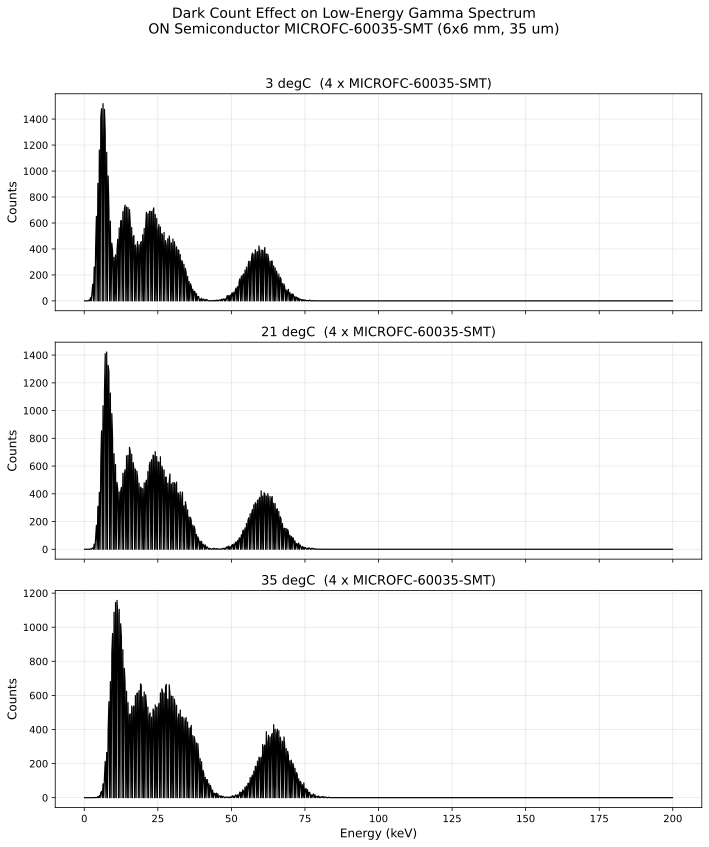

In [16]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

from models.dark_count_noise_model import simulate_sipm_spectrum

# ============================================
# Load Configuration
# ============================================

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

dc_cfg = cfg["dark_count_study"]

rng = np.random.default_rng(seed=dc_cfg["rng_seed"])

# Detector
n_sipm = dc_cfg["detector"]["n_sipm"]
pe_per_kev_single = dc_cfg["detector"]["pe_per_kev_single"]
pe_per_kev = pe_per_kev_single * n_sipm
integration_time = dc_cfg["detector"]["integration_time_s"]
detector_label = dc_cfg["detector"]["label"]

# Energy axis
e_max = dc_cfg["energy_axis"]["e_max"]
n_bins = dc_cfg["energy_axis"]["n_bins"]

# Simulation
events_per_peak = dc_cfg["simulation"]["events_per_peak"]
temperatures = dc_cfg["simulation"]["temperatures_c"]

# Isotopes
isotopes = [
    (iso["energy_kev"], iso["intensity"])
    for iso in dc_cfg["isotopes"]
]

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(len(temperatures), 1,
                         figsize=(10, 12),
                         sharex=True)

for ax, temp in zip(axes, temperatures):

    spectrum, bin_centers = simulate_sipm_spectrum(
        temperature_c    = temp,
        isotopes         = isotopes,
        events_per_peak  = events_per_peak,
        pe_per_kev       = pe_per_kev,
        n_sipm           = n_sipm,
        integration_time = integration_time,
        n_bins           = n_bins,
        e_max            = e_max,
        rng              = rng,
    )

    ax.plot(bin_centers, spectrum, color="black", linewidth=1.2)
    ax.set_title(f"{temp:.0f} degC  (4 x MICROFC-60035-SMT)")
    ax.set_ylabel("Counts")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Energy (keV)")

fig.suptitle(
    "Dark Count Effect on Low-Energy Gamma Spectrum\n"
    "ON Semiconductor MICROFC-60035-SMT (6x6 mm, 35 um)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    REPORT_DIR / "spectrum_dark_count_MICROFC60035.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path

from models.electronics_requirements_model import calculate_electronics_requirements

# ============================================
# Input Parameters
# ============================================

# From detector physics calculation (4 x 6x6 mm SiPM configuration)
SIGMA_SCINTILLATION = 0.0239  # 2.39% RMS at 662 keV
FWHM_SCINTILLATION = 0.0563   # 5.62% FWHM at 662 keV

# SiPM pulse characteristics (MICROFC-60035-SMT)
TAU_CELL_NS = 95  # Microcell recharge time constant (ns)
TAU_CELL_S = TAU_CELL_NS * 1e-9

# ADC parameters
ADC_SAMPLING_RATE_MSPS = 40  # 40 MSPS
ADC_SAMPLING_RATE_HZ = ADC_SAMPLING_RATE_MSPS * 1e6

# Design parameters
BUDGET_FRACTION = 0.3  # Electronics noise <= 30% of detector noise
N_SAMPLES_PER_EDGE = 4  # Samples across rising edge

# ============================================
# Calculate Electronics Requirements
# ============================================

requirements = calculate_electronics_requirements(
    sigma_scintillation=SIGMA_SCINTILLATION,
    fwhm_scintillation=FWHM_SCINTILLATION,
    tau_cell=TAU_CELL_S,
    adc_sampling_rate=ADC_SAMPLING_RATE_HZ,
    budget_fraction=BUDGET_FRACTION,
    n_samples_per_edge=N_SAMPLES_PER_EDGE
)

# ============================================
# Display Results
# ============================================

print("="*80)
print("ELECTRONICS REQUIREMENTS DERIVATION")
print("="*80)
print()
print("Configuration: 4 x 6x6 mm SiPM Array + NaI(Tl) 25.4 mm")
print("Reference Energy: 662 keV (Cs-137)")
print("="*80)
print()

# Section 1: Noise Budget
print("SECTION 1 -- NOISE BUDGET ALLOCATION")
print("-" * 80)
print()
print(f"Detector Statistical Resolution:")
print(f"  sigma_scintillation:        {requirements['sigma_scintillation_pct']:.2f}% RMS")
print(f"  FWHM_scintillation:     {requirements['fwhm_scintillation_pct']:.2f}%")
print()
print(f"Design Rule:")
print(f"  sigma_electronics <= {requirements['budget_fraction']:.1f} x sigma_scintillation")
print()
print(f"Derived Electronics Noise Budget:")
print(f"  sigma_electronics:          <= {requirements['sigma_elec_budget_pct']:.2f}% RMS")
print()
print(f"Verification (if electronics contributes {requirements['sigma_elec_budget_pct']:.2f}% RMS):")
print(f"  sigma_total:                {requirements['sigma_total_pct']:.2f}% RMS")
print(f"  Degradation:            {requirements['degradation_pct']:.1f}%")
print()

if requirements['degradation_pct'] < 5.0:
    print(f"  [OK] Acceptable (< 5% degradation threshold)")
else:
    print(f"  [X] Exceeds 5% degradation threshold")
print()
print(f"Derived Requirement:")
print(f"  sigma_electronics <= {requirements['sigma_elec_budget_pct']:.2f}% RMS")
print(f"  (Traceable to detector physics, not arbitrary)")
print()

# Section 2: SNR Analysis
print("="*80)
print("SECTION 2 -- DETECTOR-LIMITED SNR")
print("-" * 80)
print()
print(f"Detector Resolution:")
print(f"  FWHM:                   {requirements['fwhm_scintillation_pct']:.2f}%")
print(f"  sigma (RMS):                {requirements['sigma_scintillation_pct']:.2f}%")
print()
print(f"Equivalent SNR:")
print(f"  SNR (linear):           {requirements['snr_detector_linear']:.1f}")
print(f"  SNR (dB):               {requirements['snr_detector_db']:.1f} dB")
print()
print(f"Interpretation:")
print(f"  The detector physics limit is approximately {requirements['snr_detector_db']:.0f} dB SNR")
print(f"  at 662 keV.")
print()

# Section 3: ADC Comparison
print("="*80)
print("SECTION 3 -- ADC SPECIFICATION COMPARISON")
print("-" * 80)
print()
print(f"Typical ADC Specifications:")
print(f"  Ideal ADC SNR:          65-70 dB")
print(f"  Detector-limited SNR:   ~{requirements['snr_detector_db']:.0f} dB")
print(f"  Margin:                 ~{70 - requirements['snr_detector_db']:.0f} dB")
print()
print(f"Conclusion:")
print(f"  The ADC intrinsic noise floor is NOT the system bottleneck.")
print(f"  Detector photon statistics dominate system resolution.")
print()

# Section 4: Bandwidth Requirements
print("="*80)
print("SECTION 4 -- BANDWIDTH REQUIREMENTS DERIVATION")
print("-" * 80)
print()
print(f"SiPM Microcell Pulse Physics:")
print(f"  tau_cell:                 {requirements['tau_cell_ns']:.0f} ns")
print(f"  (Exponential recharge time constant)")
print()
print(f"ADC Sampling Constraint:")
print(f"  Sampling rate:          {requirements['adc_sampling_rate_msps']:.0f} MSPS")
print(f"  Sampling period:        {requirements['t_sample_ns']:.1f} ns")
print(f"  Samples per edge:       {requirements['n_samples_per_edge']}")
print()
print(f"Required Analog Rise Time:")
print(f"  t_rise (minimum):       {requirements['n_samples_per_edge']-1} x {requirements['t_sample_ns']:.1f} ns = {(requirements['n_samples_per_edge']-1)*requirements['t_sample_ns']:.0f} ns")
print(f"  t_rise (preferred):     {requirements['n_samples_per_edge']+1} x {requirements['t_sample_ns']:.1f} ns = {(requirements['n_samples_per_edge']+1)*requirements['t_sample_ns']:.0f} ns")
print(f"  t_rise (target):        {requirements['t_rise_required_ns']:.0f} ns")
print()
print(f"Bandwidth Derivation (f_3dB ~= 0.35 / t_rise):")
print(f"  From required rise time: {requirements['f_3db_from_rise_mhz']:.1f} MHz")
print(f"  From tau_cell:            {requirements['f_3db_from_tau_mhz']:.1f} MHz")
print(f"  Nyquist frequency:      {requirements['f_nyquist_mhz']:.0f} MHz")
print()
print(f"Derived Bandwidth Requirement:")
print(f"  f_3dB = 3 to 6 MHz")
print()
print(f"Why NOT Full Nyquist Bandwidth ({requirements['f_nyquist_mhz']:.0f} MHz)?")
print(f"  - Integrates ~6x more white noise")
print(f"  - Degrades ENOB below system requirement")
print(f"  - Provides no benefit (ADC cannot resolve < {requirements['t_sample_ns']:.0f} ns features)")
print(f"  - Makes noise floor requirement harder to meet")
print()

# Section 5: Summary
print("="*80)
print("SUMMARY -- DERIVED REQUIREMENTS")
print("="*80)
print()

summary_data = {
    'Requirement': [
        'Electronics Noise Budget',
        'Detector SNR',
        'AFE Bandwidth (-3dB)',
        'ADC Sampling Rate',
        'Max Degradation',
    ],
    'Specification': [
        f"<= {requirements['sigma_elec_budget_pct']:.2f}% RMS",
        f"~{requirements['snr_detector_db']:.0f} dB",
        f"3-6 MHz",
        f">= {requirements['adc_sampling_rate_msps']:.0f} MSPS",
        f"< 5%",
    ],
    'Achieved/Status': [
        f"{requirements['sigma_elec_budget_pct']:.2f}% RMS",
        f"{requirements['snr_detector_db']:.1f} dB",
        f"{requirements['f_3db_from_rise_mhz']:.1f} MHz (from rise time)",
        f"{requirements['adc_sampling_rate_msps']:.0f} MSPS",
        f"{requirements['degradation_pct']:.1f}% [OK]",
    ],
    'Derived From': [
        f"{requirements['budget_fraction']:.0%} x sigma_scintillation",
        "Detector photon statistics",
        "tau_cell = 95 ns, 4 samples/edge",
        "Pulse reconstruction requirement",
        "Quadrature noise sum",
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()

print("="*80)
print("All specifications are physics-derived and traceable.")
print("Ready for requirements traceability matrix.")
print("="*80)

ELECTRONICS REQUIREMENTS DERIVATION

Configuration: 4 x 6x6 mm SiPM Array + NaI(Tl) 25.4 mm
Reference Energy: 662 keV (Cs-137)

SECTION 1 -- NOISE BUDGET ALLOCATION
--------------------------------------------------------------------------------

Detector Statistical Resolution:
  sigma_scintillation:        2.39% RMS
  FWHM_scintillation:     5.63%

Design Rule:
  sigma_electronics <= 0.3 x sigma_scintillation

Derived Electronics Noise Budget:
  sigma_electronics:          <= 0.72% RMS

Verification (if electronics contributes 0.72% RMS):
  sigma_total:                2.50% RMS
  Degradation:            4.4%

  [OK] Acceptable (< 5% degradation threshold)

Derived Requirement:
  sigma_electronics <= 0.72% RMS
  (Traceable to detector physics, not arbitrary)

SECTION 2 -- DETECTOR-LIMITED SNR
--------------------------------------------------------------------------------

Detector Resolution:
  FWHM:                   5.63%
  sigma (RMS):                2.39%

Equivalent SNR:
  SNR (